Score commercial auto policies for expected claim risk
Fits a model on historical data and scores the current period

Data:
train.csv  - policies 2020-2022, includes claim outcomes
score.csv  - policies 2023-2024, no outcomes (to be scored)

In [93]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, 
    mean_absolute_error, 
    brier_score_loss, 
    roc_auc_score, 
    ConfusionMatrixDisplay, 
    classification_report, 
    confusion_matrix,
    precision_recall_curve,
    average_precision_score
)
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, FunctionTransformer
from xgboost import XGBClassifier
import joblib
from datetime import datetime
import json
import matplotlib.pyplot as plt
import seaborn as sns

from utils import (
    impute_prior_loss
)

In [77]:
# ---- load ----

dataset_type = "train"

df = pd.read_parquet(f'../data/cleaned/df_{dataset_type}_cleaned.parquet')

print(f'{dataset_type}: {df.shape}')

train: (14983, 42)


### Features

In [78]:
# ---- features ----

target_column = ["target"]

cat_cols_direct = ['coverage_type', 'business_type', 'state']
cat_cols_with_unknown = ['payment_frequency']

numeric_cols = [
    'vehicle_count', 'num_heavy_vehicles', 'total_vehicle_count',
    'vehicle_avg_age', 'mileage_per_vehicle',
    'driver_count', 'driver_avg_age',
    'years_in_business',
    'prior_apd_claim_count', 'prior_al_claim_count', 'prior_loss_amount',
    'has_large_prior_loss', 'loss_per_claim',
    'late_payment_count',

    'deductible',
    'coverage_limit_000',
    'annual_premium',
    'risk_score_external', 'risk_score_external_isna',

    'policy_length_days', 'exposure_ratio',
]

In [79]:
feature_cols = cat_cols_direct + cat_cols_with_unknown + numeric_cols

In [80]:
X = df[feature_cols]
y = df["target"]

X.shape

(14983, 25)

In [81]:
print(y.value_counts(), '\n')
print(y.value_counts(normalize=True))

target
0    13130
1     1853
Name: count, dtype: int64 

target
0    0.876327
1    0.123673
Name: proportion, dtype: float64


### Pipeline

In [82]:
# Called here bacause we need to train median for 'prior_loss_amount'
# only on X_train data

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Compute median from training data
train_median_loss = X_train.loc[
    X_train["prior_loss_amount"] > 0, "prior_loss_amount"
].median()

# Pass median
prior_loss_imputer_transformer = FunctionTransformer(
    impute_prior_loss, kw_args={"median_loss": train_median_loss}
)


# Pipeline for categorical columns (payment_frequency) to fill 'unknown'
cat_impute_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

# Pipeline for standard categoricals - most frequent
cat_direct_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent", add_indicator=True)),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

# Pipeline for standard numericals
num_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
        ("scaler", RobustScaler()),
        ]
    )


preprocessor = ColumnTransformer(
    transformers=[
        ("cat_impute", cat_impute_pipeline, cat_cols_with_unknown),
        ("cat_direct", cat_direct_pipeline, cat_cols_direct),
        ("num", num_pipeline, numeric_cols),
    ],
    remainder="drop",
)

# imbalanced claims ratio for XGBoost
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()

model = XGBClassifier(
                n_estimators=300,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.8,
                colsample_bytree=0.8,
                # scale_pos_weight=scale_pos_weight,    # tried by 1st run
                # early_stopping_rounds=50,
                scale_pos_weight=1.0,
                eval_metric="logloss",
                random_state=42,
        )


full_pipeline = Pipeline(
    steps=[
        ("custom_loss", prior_loss_imputer_transformer),
        ("preprocessor", preprocessor),
        ("classifier", model),
    ]
)

### Train Pipeline

In [83]:
full_pipeline.fit(
    X_train,
    y_train,
    )

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('custom_loss', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](25,)","['coverage_type','business_type','state',...,'risk_score_external_isna', 'policy_length_days','exposure_ratio']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,25
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function imp...0023931C7FC10>
,"kw_args kw_args: dict, default=NoneDictionary of additional keyword arguments to pass to func... versionadded:: 0.18",{'median_loss': np.float64(11205.415)}
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None


### Predict

In [84]:
predicted_risk_scores = full_pipeline.predict_proba(X_test)[:, 1]

### Validatation Metrics

In [95]:
auc = roc_auc_score(y_test, predicted_risk_scores)
gini = 2 * auc - 1
brier = brier_score_loss(y_test, predicted_risk_scores)

print(f"ROC-AUC:     {auc:.4f}")
print(f"Gini Score:  {gini:.4f}")
print(f"Brier Score: {brier:.4f}")

# Attach to results DataFrame
results_df = X_test.copy()
results_df["actual_target"] = y_test
results_df["predicted_risk_score"] = predicted_risk_scores

# Display head(10) results
# results_df[["actual_target", "predicted_risk_score"]].head(10)

ROC-AUC:     0.6436
Gini Score:  0.2872
Brier Score: 0.1066


In [94]:
pr_auc = average_precision_score(y_test, predicted_risk_scores)

print(f"PR-AUC (Average Precision): {pr_auc:.4f}")
print(f"Baseline (Náhodný model):   {y_test.mean():.4f}")

PR-AUC (Average Precision): 0.1900
Baseline (Náhodný model):   0.1238


| Metric     | 1st    | 2nd    | 3rd    | 4rd    |
|------------|--------|--------|--------|--------|
|ROC-AUC:    | 0.6386 | 0.6436 | 0.6494 | 0.6586 |
|Gini Score: | 0.2773 | 0.2872 | 0.2989 | 0.3172 |
|Brier Score:| 0.1773 | 0.1066 | 0.1060 | 0.1051 |

### Metadata

In [86]:
metadata = {
    "model_type": "XGBClassifier",
    "training_date": datetime.now().isoformat(),
    "features": list(X_train.columns),
    "hyperparameters": model.get_params(),
    "validation_metrics": {
        "roc_auc": round(auc,4),
        "gini": round(gini,4),
        "brier_score_loss": round(brier,4),
    }
}

with open("../models/xgb_risk_scorer_meta.json", "w") as f:
    json.dump(metadata, f, indent=4)

### Classification Report

In [87]:
# Treshold: 90. percentil (top 10 % - most risky)
custom_threshold = np.percentile(predicted_risk_scores, 90)
y_pred_custom = (predicted_risk_scores >= custom_threshold).astype(int)

report_dict = classification_report(
    y_test, y_pred_custom, target_names=["No Claim", "Claim"], output_dict=True
)

df_report = (
    pd.DataFrame(report_dict).iloc[:-1, :].T
)

report_str = classification_report(y_test, y_pred_custom, target_names=["No Claim", "Claim"])

print(confusion_matrix(y_test, y_pred_custom))
print(report_str)

with open("../reports/figures/classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report_str)

[[2390  236]
 [ 307   64]]
              precision    recall  f1-score   support

    No Claim       0.89      0.91      0.90      2626
       Claim       0.21      0.17      0.19       371

    accuracy                           0.82      2997
   macro avg       0.55      0.54      0.54      2997
weighted avg       0.80      0.82      0.81      2997



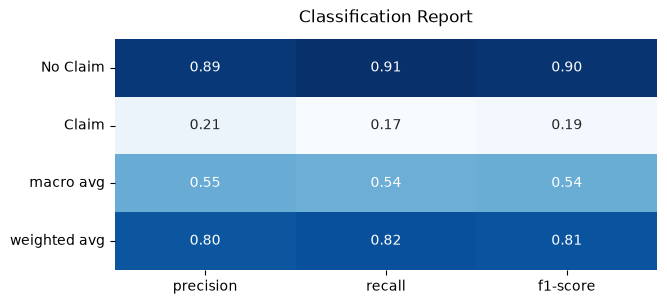

In [88]:
fig, ax = plt.subplots(figsize=(7, 3))
sns.heatmap(
    pd.DataFrame(report_dict).iloc[:-1, :].T.drop("accuracy", errors="ignore"),
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=False,
    ax=ax,
)
plt.title("Classification Report", pad=12)

plt.savefig("../reports/figures/classification_report.png", dpi=300, bbox_inches="tight")
plt.show()

### Classification Matrix

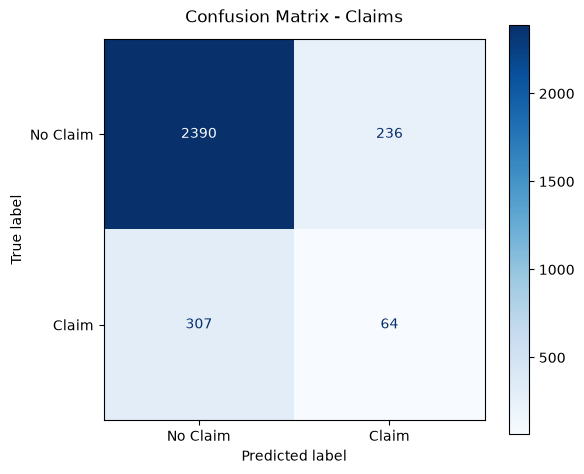

In [89]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_custom,
    display_labels=["No Claim", "Claim"],
    cmap=plt.cm.Blues,
    values_format="d",
    ax=ax,
)

plt.title("Confusion Matrix - Claims", fontsize=12, pad=12)
plt.tight_layout()

plt.savefig("../reports/figures/confusion_matrix.png", dpi=300)
plt.show()

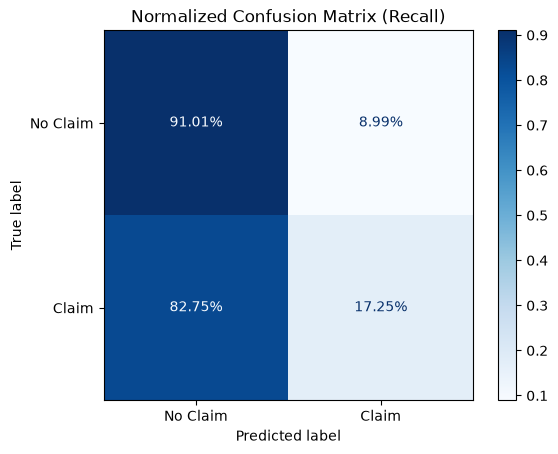

In [90]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_custom,
    display_labels=["No Claim", "Claim"],
    normalize="true",
    values_format=".2%",
    cmap="Blues",
)
plt.title("Normalized Confusion Matrix (Recall)", fontsize=12)
plt.savefig("../reports/figures/normalized_confusion_matrix.png", dpi=300)
plt.show()

### Save Model

In [91]:
joblib.dump(full_pipeline, "../models/risk_pipeline.joblib")

['../models/risk_pipeline.joblib']